## Load packages

In [1]:
import os
import glob

import chardet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno # run first '%pip install missingno'
from ydata_profiling import ProfileReport # run first '%pip install ydata_profiling'

import xml.etree.ElementTree as ET # pip install lxml

import sys
sys.path.insert(0, '..')
from models.tools import show_info, get_alerts, dump_missing, parse_xml, plot_correlation, drop_na_and_zeros, get_common_index

pd.set_option('display.max_rows', 100)

/Users/jshen/neuefische/capstone_solar_energy/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## OPSD

> https://open-power-system-data.org/

In [2]:
input_file = "../data/OPSD/renewable_power_plants_DE.csv"

# df = pd.read_csv(input_file, delimiter=',', encoding="utf-8", parse_dates=["commissioning_date"])

# df.head()

### Columns
| Name                | Description                                                                   | Type     |
|---------------------|-------------------------------------------------------------------------------|----------|
| electrical_capacity | Installed electrical capacity in MW                                           | number   |
| energy_source_level_1 | Type of energy source (e.g. Renewable energy)                               | string   |
| energy_source_level_2 | Type of energy source (e.g. Wind, Solar)                                   | string   |
| energy_source_level_3 | Subtype of energy source (e.g. Biomass and biogas)                         | string   |
| technology          | Technology to harvest energy source (e.g. Onshore, Photovoltaics)             | string   |
| data_source         | Source of database entry                                                      | string   |
| nuts_1_region       | The code of the NUTS 1 region the facility is in (e.g. DE1)                   | string   |
| nuts_2_region       | The code of the NUTS 2 region the facility is in (e.g. DE11)                  | string   |
| nuts_3_region       | The code of the NUTS 3 region the facility is in (e.g. DE111)                 | string   |
| lon                 | Longitude coordinates                                                          | number   |
| lat                 | Latitude coordinates                                                           | number   |
| municipality        | Name of German Gemeinde (municipality)                                        | string   |
| municipality_code   | German Gemeindenummer (municipalitiy number)                                  | string   |
| postcode            | German zip-code                                                               | string   |
| address             | Street name or name of land parcel                                            | string   |
| federal_state       | Name of German administrative level 'Bundesland'                              | string   |
| commissioning_date  | Date of commissioning of specific unit                                        | date     |
| decommissioning_date| Date of decommissioning of specific unit                                      | date     |
| voltage_level       | Voltage level of grid connection                                              | string   |
| eeg_id              | Power plant EEG (German feed-in tariff law) remuneration number               | string   |
| dso                 | Name of distribution system operator of the region the plant is located in    | string   |
| dso_id              | Company number of German distribution grid operator                           | string   |
| tso                 | Name of transmission system operator of the area the plant is located         | string   |

Refer to:
> https://data.open-power-system-data.org/renewable_power_plants/2020-08-25/datapackage.json

In [3]:
# df.iloc[:, [14, 19]].columns

In [4]:
# Detect encoding of the XML file
# with open(input_file, 'rb') as f:
#     result = chardet.detect(f.read())
# encoding = result['encoding']

# print(encoding)

In [5]:
# Columns can be dropped right away
# "energy_source_level_1" - single value
# "decommissioning_date" - all null

"""
"energy_source_level_3" has 1754346 (99.2%) missing values
"municipality" has 1073178 (60.7%) missing values
"address" has 1764642 (99.8%) missing values
"decommissioning_date" has 1768745 (100.0%) missing values
"eeg_id" has 1768227 (> 99.9%) missing values
"""

# show_info(df)
1

1

In [6]:
# Get the latest date in the OPSD dataset

# df["commissioning_date"].unique().max() # Timestamp('2018-06-22 00:00:00')

In [7]:
# df_profile = ProfileReport(df, title="Profiling Report")
# Export the profile report
# output_report = "output/df_profile.html"
# df_profile.to_file(output_report)

# Open the report in the default browser
# !open {output_report}

# Get the alters from the profiling report
# get_alerts(output_report)

### House holds

In [8]:
input_file_household = "../data/OPSD/household_data_15min_singleindex.csv"

# df_household = pd.read_csv(input_file_household, delimiter=',', encoding="utf-8", parse_dates=["commissioning_date"])

df_household = pd.read_csv(input_file_household, parse_dates=["utc_timestamp"]) # no idea why "cet_cest_timestamp" does not work
df_household.drop(columns=["cet_cest_timestamp", "interpolated"], inplace=True)
df_household.head()


,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine
0,2014-12-11 17:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11 18:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11 18:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11 18:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_household.loc[:, df_household.columns.str.contains('residential', case=False)].columns

Index(['DE_KN_residential1_dishwasher', 'DE_KN_residential1_freezer',
       'DE_KN_residential1_grid_import', 'DE_KN_residential1_heat_pump',
       'DE_KN_residential1_pv', 'DE_KN_residential1_washing_machine',
       'DE_KN_residential2_circulation_pump', 'DE_KN_residential2_dishwasher',
       'DE_KN_residential2_freezer', 'DE_KN_residential2_grid_import',
       'DE_KN_residential2_washing_machine',
       'DE_KN_residential3_circulation_pump', 'DE_KN_residential3_dishwasher',
       'DE_KN_residential3_freezer', 'DE_KN_residential3_grid_export',
       'DE_KN_residential3_grid_import', 'DE_KN_residential3_pv',
       'DE_KN_residential3_refrigerator', 'DE_KN_residential3_washing_machine',
       'DE_KN_residential4_dishwasher', 'DE_KN_residential4_ev',
       'DE_KN_residential4_freezer', 'DE_KN_residential4_grid_export',
       'DE_KN_residential4_grid_import', 'DE_KN_residential4_heat_pump',
       'DE_KN_residential4_pv', 'DE_KN_residential4_refrigerator',
       'DE_KN_reside

In [10]:
# Create a dictionary to store each DataFrame
household_df_dict = {}

# Define the residential categories
hh_items = ['residential1', 'residential2', 'residential3',
            'residential4', 'residential5', 'residential6']

# Loop through each category
for hh in hh_items:
    # Create a mask that selects columns containing the current residential category
    mask = df_household.columns.str.contains(hh)
    
    # Use the mask to select the appropriate columns from the original DataFrame
    household_df_dict[hh] = df_household.loc[:, mask].copy()

    # Add the date time back
    household_df_dict[hh]["utc_timestamp"] = df_household.loc[:, "utc_timestamp"]
    household_df_dict[hh].set_index("utc_timestamp", inplace=True)
    
    # Remove the common prefix from each column name
    household_df_dict[hh].columns = household_df_dict[hh].columns.str.replace(f'DE_KN_{hh}_', '')

    try:
        # Drop rows where pv is na
        # Remove rows where the first values of 'pv' are 0
        household_df_dict[hh] = drop_na_and_zeros(household_df_dict[hh], 'pv')

        # Select the columns to be summed up
        cols_to_sum = [col for col in household_df_dict[hh].columns if not ('grid_' in col or 'pv' in col)]

        # Create the new column
        household_df_dict[hh]["load"] = household_df_dict[hh][cols_to_sum].sum(axis=1)

        # Store the original first row
        original_first_row = household_df_dict[hh].iloc[0].copy()

        # Diff
        household_df_dict[hh] = household_df_dict[hh].diff()

        # Fill the first row using the original values
        household_df_dict[hh].iloc[0] = original_first_row

        # Resample
        household_df_dict[hh] = household_df_dict[hh].resample('60T').sum() # '60T' specifies 60-minute intervals

    except:
        print(f"{hh!r} does not have 'pv' generation")
        del household_df_dict[hh]

    

'residential2' does not have 'pv' generation
'residential5' does not have 'pv' generation


In [11]:
common_idx = get_common_index(household_df_dict)

print(f"The common time span is: {common_idx[0]} - {common_idx[-1]}")

The common time span is: 2016-02-29 06:00:00+00:00 - 2017-03-12 23:00:00+00:00


In [12]:
for key, _ in household_df_dict.items():
    start = household_df_dict[key].index[0]
    end = household_df_dict[key].index[-1]
    print(f"{key!r}: {start} - {end}")
    # print(household_df_dict[key].columns.to_list())

'residential1': 2015-05-21 15:00:00+00:00 - 2017-03-12 23:00:00+00:00
'residential3': 2016-02-29 06:00:00+00:00 - 2018-09-25 11:00:00+00:00
'residential4': 2015-10-11 06:00:00+00:00 - 2018-02-04 23:00:00+00:00
'residential6': 2015-10-25 06:00:00+00:00 - 2018-04-08 22:00:00+00:00


In [13]:
show_info(household_df_dict["residential1"])

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,dishwasher,float64,15873,0.0,529,...
1,freezer,float64,15873,0.0,241,...
2,grid_import,float64,15873,0.0,3485,...
3,heat_pump,float64,15873,0.0,4950,...
4,pv,float64,15873,0.0,5065,...
5,washing_machine,float64,15873,0.0,703,...
6,load,float64,15873,0.0,7032,...


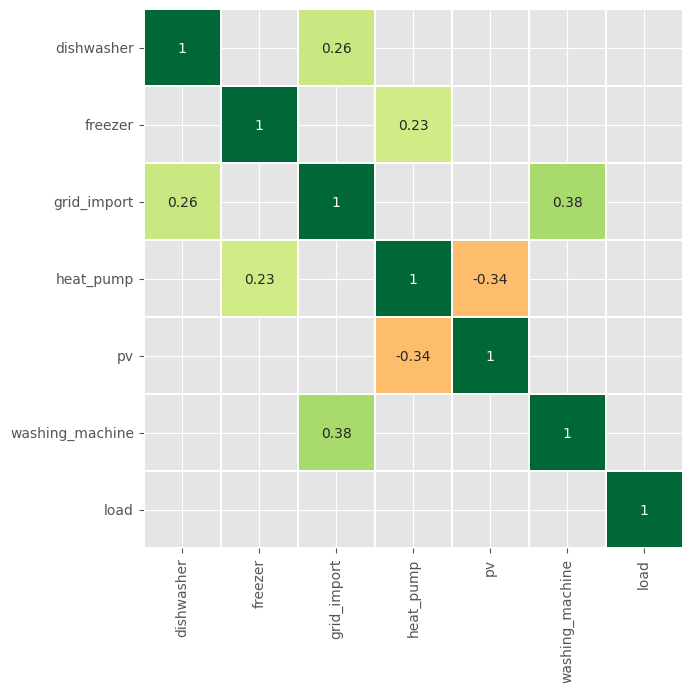

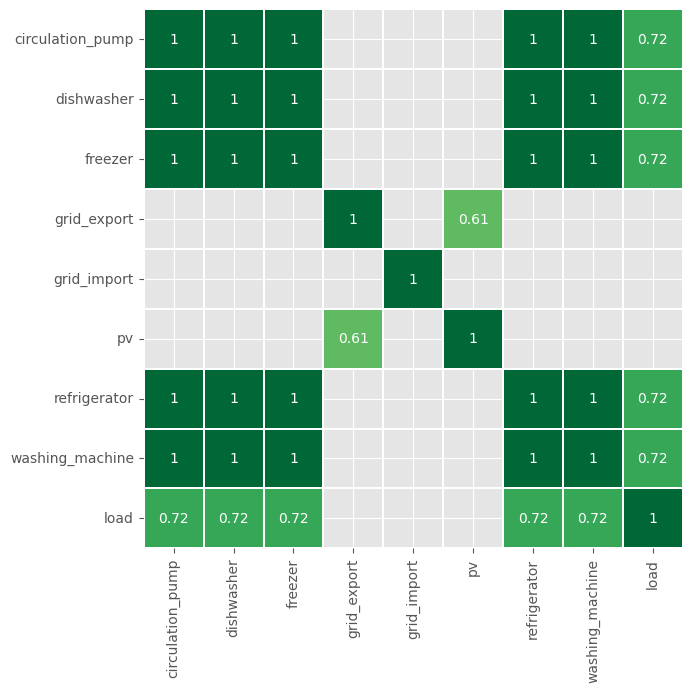

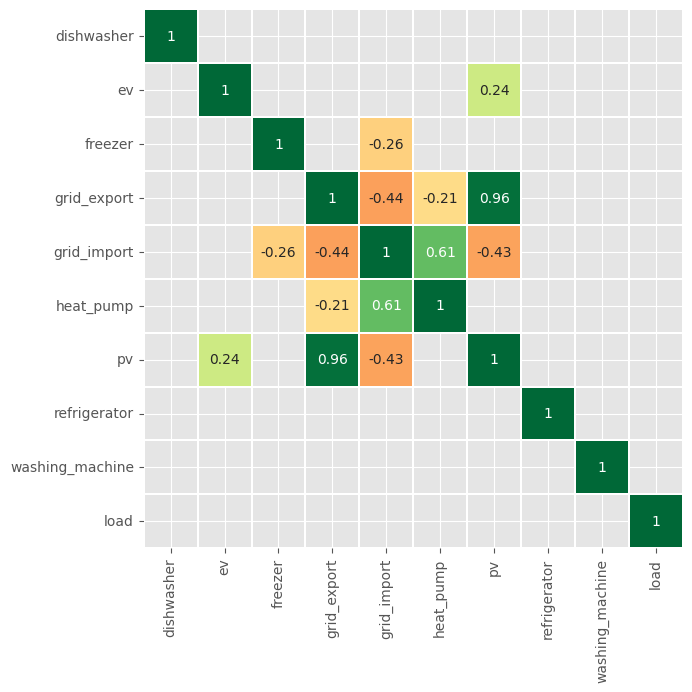

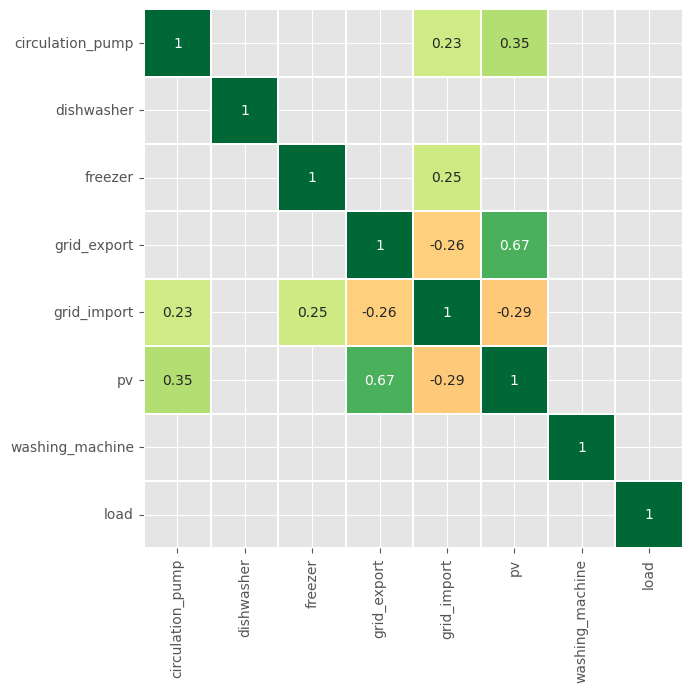

In [14]:
plt.style.use("ggplot")
for key, _ in household_df_dict.items():
    df_ = household_df_dict[key].dropna()
    col_corr = df_.columns.to_list()
    plot_correlation(df_, col_corr)

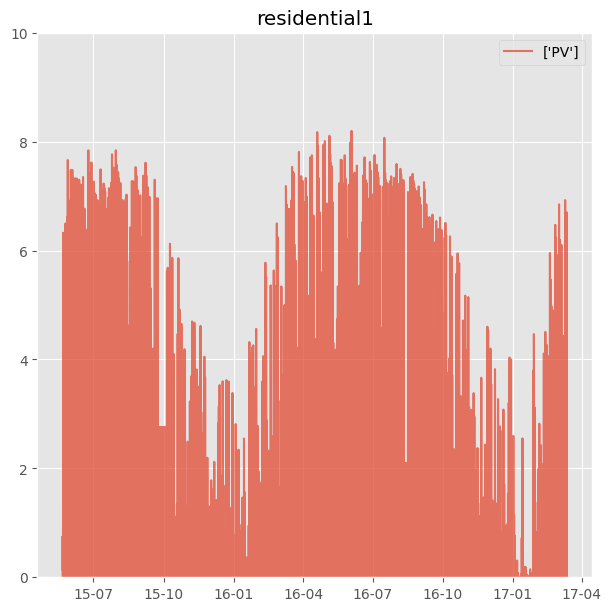

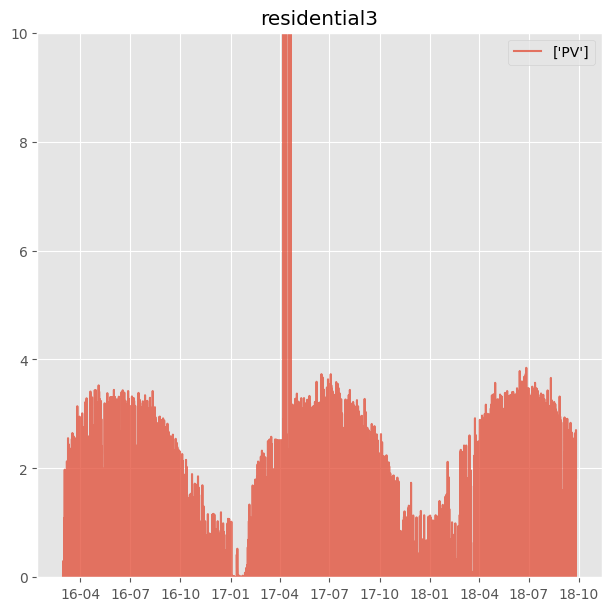

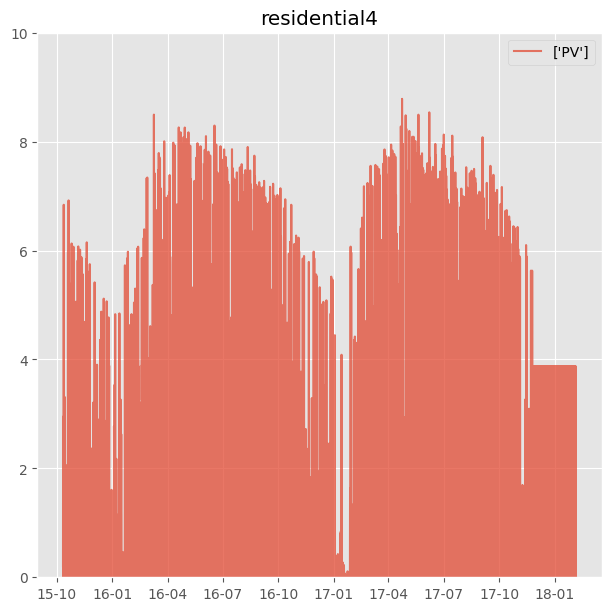

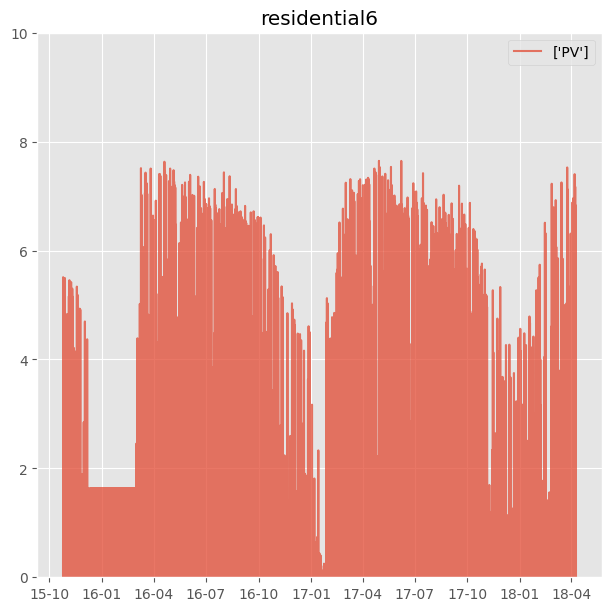

In [17]:
plt.style.use("ggplot")
for key, _ in household_df_dict.items():
    df_ = household_df_dict[key].copy()
    # Filter out the data of the common time span
    # df_ = df_.loc[common_idx, :]

    _, ax = plt.subplots(1,1, figsize=(6, 6), constrained_layout=True, dpi=100)

    # ax.plot(df_.index, df_[['pv', 'load']], label=["PV", "Load"], alpha=0.75)
    ax.plot(df_.index, df_[['pv']], label=["PV"], alpha=0.75)

    ax.set(
        ylim = (0, 50),
        title = key,
    )

    # Get the existing labels
    labels = [item.get_text() for item in ax.get_xticklabels()]

    # Modify the labels
    new_labels = [label.replace('20', '') for label in labels]

    # Set the new labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(new_labels)

    #print(ax.get_xticklabels())

    plt.legend()

    plt.show()

In [16]:
show_info(household_df_dict["residential3"])

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,circulation_pump,float64,22542,0.0,354,...
1,dishwasher,float64,22542,0.0,535,...
2,freezer,float64,22542,0.0,210,...
3,grid_export,float64,22542,0.0,4394,...
4,grid_import,float64,22542,0.0,3637,...
5,pv,float64,22542,0.0,5678,...
6,refrigerator,float64,22542,0.0,209,...
7,washing_machine,float64,22542,0.0,1505,...
8,load,float64,22542,0.0,2670,...


In [17]:
show_info(household_df_dict["residential3"].dropna())

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,circulation_pump,float64,22542,0.0,354,...
1,dishwasher,float64,22542,0.0,535,...
2,freezer,float64,22542,0.0,210,...
3,grid_export,float64,22542,0.0,4394,...
4,grid_import,float64,22542,0.0,3637,...
5,pv,float64,22542,0.0,5678,...
6,refrigerator,float64,22542,0.0,209,...
7,washing_machine,float64,22542,0.0,1505,...
8,load,float64,22542,0.0,2670,...


In [18]:
household_df_dict["residential3"].columns

Index(['circulation_pump', 'dishwasher', 'freezer', 'grid_export',
       'grid_import', 'pv', 'refrigerator', 'washing_machine', 'load'],
      dtype='object')

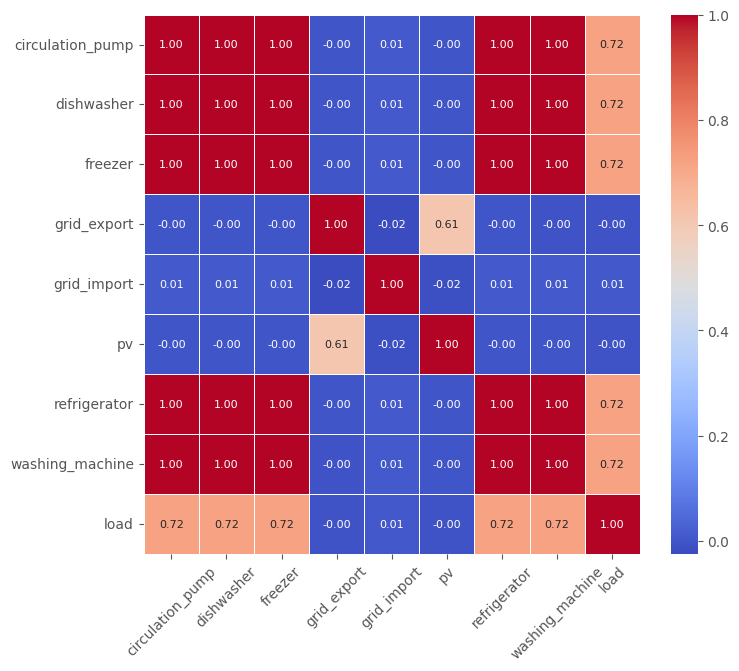

In [19]:
import seaborn as sns
#col_corr = household_df_dict["residential1"].dropna().columns.to_list()

#plot_correlation(household_df_dict["residential3"], col_corr)

dfc = household_df_dict["residential3"].copy()
plt.figure(figsize=(8, 7))
corr_matrix = dfc.corr()

# Heat map
#filter = (corr_df >= 0.2) | (corr_df <= -0.2)

ax = sns.heatmap(corr_matrix, linewidths = .5, annot = True, fmt=".2f", annot_kws={"fontsize":8},cmap= 'coolwarm' )
ax.tick_params(axis='x', rotation=45)

plt.show()

In [20]:
df_profile = ProfileReport(household_df_dict["residential1"].dropna(), title="Profiling Report")
# Export the profile report
output_report = "../output/hh_profile_r1na.html"
df_profile.to_file(output_report)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 260.71it/s]


In [21]:
! open {output_report}

In [22]:
# name_dict = {
#     "DE_KN_": "",
#     "industrial1": "ind1",
#     "industrial2": "ind2",
#     "industrial3": "ind3",
#     "residential1": "res1",
#     "residential2": "res2",
#     "residential3": "res3",
#     "residential4": "res4",
#     "residential5": "res5",
#     "residential6": "res6",
# }

# for old_name, new_name in name_dict.items():
#     #print(old_name, new_name)
#     df_household.rename(columns=lambda col_name: col_name.replace(old_name, new_name) if old_name in col_name else col_name, inplace=True)
# df_household.rename(columns=lambda col_name: col_name.replace('DE_KN_', '') if 'DE_KN_' in col_name else col_name, inplace=True)
# df_household.rename(columns=lambda col_name: col_name.replace('industrial1', 'ind1') if 'industrial1' in col_name else col_name, inplace=True)
# df_household.rename(columns=lambda col_name: col_name.replace('industrial2', 'ind2') if 'industrial2' in col_name else col_name, inplace=True)
# df_household.rename(columns=lambda col_name: col_name.replace('industrial2', 'ind2') if 'industrial2' in col_name else col_name, inplace=True)
# df_household.rename(columns=lambda col_name: col_name.replace('industrial2', 'ind2') if 'industrial2' in col_name else col_name, inplace=True)
# df_household.rename(columns=lambda col_name: col_name.replace('industrial2', 'ind2') if 'industrial2' in col_name else col_name, inplace=True)
# df_household.rename(columns=lambda col_name: col_name.replace('industrial2', 'ind2') if 'industrial2' in col_name else col_name, inplace=True)

In [23]:
show_info(df_household)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,utc_timestamp,"datetime64[ns, UTC]",153810,0.00,153810,...
1,DE_KN_industrial1_grid_import,float64,65730,57.27,65730,...
2,DE_KN_industrial1_pv_1,float64,69151,55.04,30693,...
3,DE_KN_industrial1_pv_2,float64,69151,55.04,26462,...
4,DE_KN_industrial2_grid_import,float64,45113,70.67,37008,...
5,DE_KN_industrial2_pv,float64,47998,68.79,21492,...
6,DE_KN_industrial2_storage_charge,float64,39010,74.64,35904,...
7,DE_KN_industrial2_storage_decharge,float64,39010,74.64,7638,...
8,DE_KN_industrial3_area_offices,float64,57437,62.66,56191,...
9,DE_KN_industrial3_area_room_1,float64,57437,62.66,57168,...


In [24]:
# Drop entries associated with residential 2 as it has no pv information
df_household = df_household.loc[:, ~df_household.columns.str.contains('res2', case=False)]

#
# Deal with nulls
#

# 
df_temp = df_household.loc[:, df_household.columns.str.contains('_pv', case=False)].copy()
df_temp.loc[:, "utc_timestamp"] = df_household["utc_timestamp"]

# Create a boolean mask where True indicates periods with any missing values across features
missing_periods = df_temp.isnull().any(axis=1)

# Apply the negative mask to get only the periods with no missing values
# Obtain the minimum and maximum timestamps in df_temp where there are no missing periods
start_date = df_temp[~missing_periods]["utc_timestamp"].min()
end_date = df_temp[~missing_periods]["utc_timestamp"].max()

# Use boolean indexing to select only the rows in df that fall within this range
filter = (df_household["utc_timestamp"] >= start_date) & (df_household["utc_timestamp"] <= end_date)
df_household_cut = df_household[filter]


show_info(df_household_cut)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,utc_timestamp,"datetime64[ns, UTC]",35701,0.00,35701,...
1,DE_KN_industrial1_grid_import,float64,35701,0.00,35701,...
2,DE_KN_industrial1_pv_1,float64,35701,0.00,15230,...
3,DE_KN_industrial1_pv_2,float64,35701,0.00,13328,...
4,DE_KN_industrial2_grid_import,float64,35701,0.00,29908,...
5,DE_KN_industrial2_pv,float64,35701,0.00,17102,...
6,DE_KN_industrial2_storage_charge,float64,30235,15.31,27988,...
7,DE_KN_industrial2_storage_decharge,float64,30235,15.31,5633,...
8,DE_KN_industrial3_area_offices,float64,35701,0.00,34455,...
9,DE_KN_industrial3_area_room_1,float64,35701,0.00,35459,...


In [25]:
df_household_cut.head()

,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine
42622,2016-02-28 17:15:00+00:00,43514.405,538.933,365.531,315.532,2629.077,NaN,NaN,4228.632,1418.868,...,1076.247,111.510,78.381,145.804,15.762,58.714,NaN,1948.696,954.123,18.650
42623,2016-02-28 17:30:00+00:00,43522.155,538.933,365.531,317.032,2629.077,NaN,NaN,4228.807,1418.928,...,1076.614,111.528,78.381,145.823,15.762,58.722,NaN,1948.896,954.123,18.650
42624,2016-02-28 17:45:00+00:00,43528.905,538.933,365.531,318.270,2629.077,NaN,NaN,4228.987,1418.988,...,1076.759,111.549,78.381,145.832,15.762,58.722,NaN,1949.086,954.123,18.650
42625,2016-02-28 18:00:00+00:00,43534.905,538.933,365.531,319.286,2629.077,NaN,NaN,4229.177,1419.053,...,1076.849,111.563,78.381,145.839,15.762,58.733,NaN,1949.296,954.123,18.866
42626,2016-02-28 18:15:00+00:00,43543.155,538.933,365.531,320.383,2629.077,NaN,NaN,4229.342,1419.118,...,1076.929,111.568,78.381,145.846,15.762,58.737,NaN,1949.506,954.123,18.879


In [26]:
df_household_cut.set_index('utc_timestamp', inplace=True) # ensure 'utc_timestamp' is the index
# df_household_cut = df_household_cut.resample('60T').sum() # '60T' specifies 60-minute intervals

df_household_cut.head()

,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,DE_KN_industrial3_area_room_2,...,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2016-02-28 17:15:00+00:00,43514.405,538.933,365.531,315.532,2629.077,NaN,NaN,4228.632,1418.868,6931.936,...,1076.247,111.510,78.381,145.804,15.762,58.714,NaN,1948.696,954.123,18.650
2016-02-28 17:30:00+00:00,43522.155,538.933,365.531,317.032,2629.077,NaN,NaN,4228.807,1418.928,6932.266,...,1076.614,111.528,78.381,145.823,15.762,58.722,NaN,1948.896,954.123,18.650
2016-02-28 17:45:00+00:00,43528.905,538.933,365.531,318.270,2629.077,NaN,NaN,4228.987,1418.988,6932.606,...,1076.759,111.549,78.381,145.832,15.762,58.722,NaN,1949.086,954.123,18.650
2016-02-28 18:00:00+00:00,43534.905,538.933,365.531,319.286,2629.077,NaN,NaN,4229.177,1419.053,6932.942,...,1076.849,111.563,78.381,145.839,15.762,58.733,NaN,1949.296,954.123,18.866
2016-02-28 18:15:00+00:00,43543.155,538.933,365.531,320.383,2629.077,NaN,NaN,4229.342,1419.118,6933.277,...,1076.929,111.568,78.381,145.846,15.762,58.737,NaN,1949.506,954.123,18.879


In [27]:
df_household_r1 = df_household_cut.loc[:, df_household_cut.columns.str.contains('residential1_', case=False)].copy()

show_info(df_household_r1)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,DE_KN_residential1_dishwasher,float64,35701,0.0,1616,...
1,DE_KN_residential1_freezer,float64,35701,0.0,32110,...
2,DE_KN_residential1_grid_import,float64,35701,0.0,35701,...
3,DE_KN_residential1_heat_pump,float64,35701,0.0,23727,...
4,DE_KN_residential1_pv,float64,35701,0.0,16407,...
5,DE_KN_residential1_washing_machine,float64,35701,0.0,5365,...


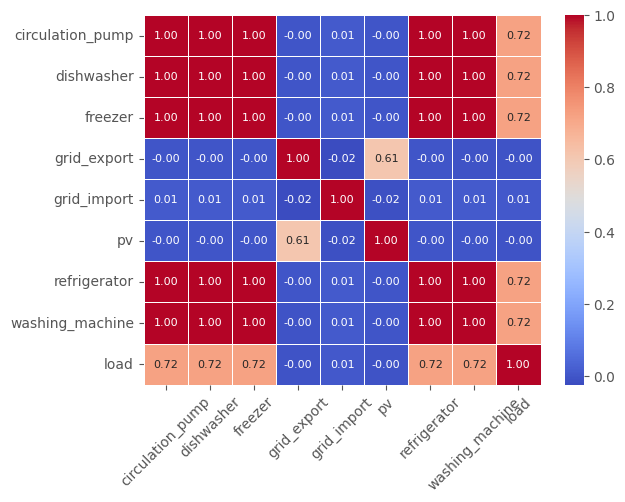

In [28]:
plt.style.use("ggplot")

corr_mtrx = df_household_r1.corr()

ax = sns.heatmap(corr_matrix, linewidths = .5, annot = True, fmt=".2f", annot_kws={"fontsize":8},cmap= 'coolwarm' )
ax.tick_params(axis='x', rotation=45)

plt.show()

<Axes: xlabel='utc_timestamp'>

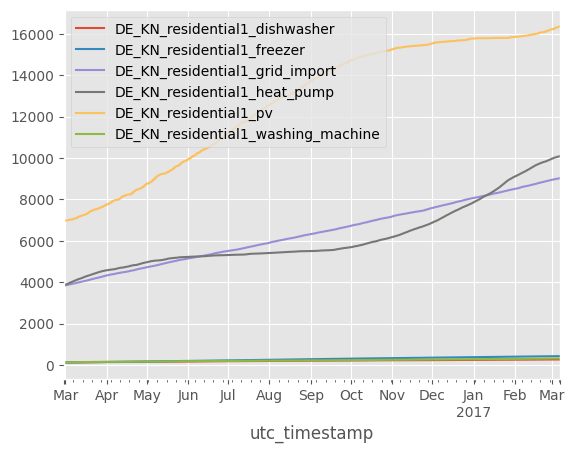

In [29]:
df_household_r1.plot()

In [30]:
# df_hh_r1 = df_household_r1.diff()

# plt.plot(df_hh_r1.index, df_hh_r1[['res1_pv', "res1_dishwasher"]], alpha=0.75)
# plt.show()

In [31]:

# Open the report in the default browser
# !open {output_report}

# Get the alters from the profiling report
# get_alerts(output_report)

## MaStR

- Since August 2014 the BNetzA is responsible to publish the renewable power plants register. The legal framework for the register is specified in the EEG 2014 (German) (English). All power plants are listed in a new format: two separate MS-Excel and CSV files for roof-mounted PV power plants 'PV-Datenmeldungen' and all other renewable power plants ' Anlagenregister'.
- From the beginning of 2019, BNetzA has switched to the Marktstammdatenregister (**MaStR**, central register for installation data). This is, however, not used yet for OPSD data. We will change to using the MaStR most likely for the 2020 version of the OPSD data package.
- **MaStR** https://www.marktstammdatenregister.de/MaStR

### AnlagenEegSolar - plants

"AnlagenEegSolar_1.xml" .. "AnlagenEegSolar_29.xml"

dff = pd.read_csv("./data/MaStR/Gesamtdatenexport_20230401_22.2/AnlagenEegSolar_5.xml")

#### single-file processing

In [32]:
# Downloaded from
# https://www.marktstammdatenregister.de/MaStR/Datendownload
input_file_plant = "../data/MaStR/Gesamtdatenexport_20230717_23.1/AnlagenEegSolar_29.xml" # 

df_plant = parse_xml(input_file_plant)

df_plant.rename(columns={
    "Registrierungsdatum": "registration_date",
    "DatumLetzteAktualisierung": "last_updated_date",
    "EegInbetriebnahmedatum": "eeg_commissioning_date",
    "EegMaStRNummer": "eegMaStR_number",
    "InanspruchnahmeZahlungNachEeg": "claim_payment_after_eeg",
    "AnlagenschluesselEeg": "plant_key_eeg",
    "AnlagenkennzifferAnlagenregister_nv": "plant_identification_number_plant_register_nv",
    "InstallierteLeistung": "installed_capacity",
    "RegistrierungsnummerPvMeldeportal_nv": "registration_number_pv_reporting_portal_nv",
    "AusschreibungZuschlag": "tender_award",
    "AnlageBetriebsstatus": "plant_operating_status",
    "VerknuepfteEinheitenMaStRNummern": "linked_units_MaStR_numbers",
    "RegistrierungsnummerPvMeldeportal":"registration_number_PV_Meldeportal",
}, 
inplace=True,
)


df_plant.head()

,registration_date,last_updated_date,eeg_commissioning_date,eegMaStR_number,plant_identification_number_plant_register_nv,installed_capacity,registration_number_pv_reporting_portal_nv,MieterstromZugeordnet,tender_award,plant_operating_status,linked_units_MaStR_numbers,plant_key_eeg,registration_number_PV_Meldeportal,ZugeordneteGebotsmenge,Zuschlagsnummer,MieterstromMeldedatum,MieterstromErsteZuordnungZuschlag,AnlagenkennzifferAnlagenregister
0,2023-03-18,2023-03-19T17:13:21.8900234,2023-03-17,EEG929261972751,1,13.940,0,0,0,35,SEE911396829383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-03-18,2023-06-13T16:39:52.8220185,2023-02-14,EEG940768360889,1,10.010,0,0,0,35,SEE987349120333,E31177010000000005007309750-00000,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-03-18,2023-03-18T18:53:48.9145747,2023-03-13,EEG926906060460,1,8.610,0,0,0,35,SEE982850998754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-03-18,2023-03-18T18:32:13.0259815,2023-02-14,EEG984544903419,1,11.745,0,0,0,35,SEE943535398375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-03-18,2023-03-18T18:32:16.7549095,2023-03-04,EEG970206696706,1,0.600,0,0,0,35,SEE980728187613,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
show_info(df_plant)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,registration_date,object,100000,0.00,129,...
1,last_updated_date,object,100000,0.00,99994,...
2,eeg_commissioning_date,object,99992,0.01,2015,...
3,eegMaStR_number,object,100000,0.00,100000,...
4,plant_identification_number_plant_register_nv,object,100000,0.00,2,"{'1': 74377, '0': 25623}"
5,installed_capacity,object,100000,0.00,3578,...
6,registration_number_pv_reporting_portal_nv,object,100000,0.00,2,"{'0': 99265, '1': 735}"
7,MieterstromZugeordnet,object,90944,9.06,2,"{'0': 90651, '1': 293}"
8,tender_award,object,93913,6.09,2,"{'0': 93804, '1': 109}"
9,plant_operating_status,object,100000,0.00,4,"{'35': 99783, '31': 107, '38': 82, '37': 28}"


In [34]:
column_to_drop = [
    #"claim_payment_after_eeg", # highly skewed
    "MieterstromZugeordnet", # highly missing and skewed
    "tender_award", # highly skewed
    "AnlagenkennzifferAnlagenregister", # highly missing
    "ZugeordneteGebotsmenge", # highly missing
    "Zuschlagsnummer", # highly missing
    "MieterstromMeldedatum", # highly missing
    "MieterstromErsteZuordnungZuschlag", # highly missing
    "registration_number_PV_Meldeportal",
]
df_plant.drop(columns=column_to_drop, inplace=True)

In [35]:
show_info(df_plant)
# dump_missing(df_plant)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,registration_date,object,100000,0.00,129,...
1,last_updated_date,object,100000,0.00,99994,...
2,eeg_commissioning_date,object,99992,0.01,2015,...
3,eegMaStR_number,object,100000,0.00,100000,...
4,plant_identification_number_plant_register_nv,object,100000,0.00,2,"{'1': 74377, '0': 25623}"
5,installed_capacity,object,100000,0.00,3578,...
6,registration_number_pv_reporting_portal_nv,object,100000,0.00,2,"{'0': 99265, '1': 735}"
7,plant_operating_status,object,100000,0.00,4,"{'35': 99783, '31': 107, '38': 82, '37': 28}"
8,linked_units_MaStR_numbers,object,100000,0.00,100000,...
9,plant_key_eeg,object,22524,77.48,22478,...


#### batch-file processing

In [36]:
def parse_xml_batch(folder_path):
    # Define a list to hold DataFrames
    all_data = []

    # Get a list of all XML files in the folder
    xml_files = glob.glob(os.path.join(folder_path, "AnlagenEegSolar_*.xml"))

    # Process each XML file
    for input_file in xml_files:
        # Handle the XML file, Convert the data to a DataFrame
        df_  = parse_xml(input_file)
        # Append the DataFrame to the list
        all_data.append(df_)

    # Concatenate all DataFrames in the list into a single DataFrame
    df_all = pd.concat(all_data, ignore_index=True)

    return df_all

folder_path = "../data/MaStR/Gesamtdatenexport_20230717_23.1/"
df_plants = parse_xml_batch(folder_path)

In [37]:
df_plants.rename(columns={
    "Registrierungsdatum": "registration_date",
    "DatumLetzteAktualisierung": "last_updated_date",
    "EegInbetriebnahmedatum": "eeg_commissioning_date",
    "EegMaStRNummer": "eegMaStR_number",
    "InanspruchnahmeZahlungNachEeg": "claim_payment_after_eeg",
    "AnlagenschluesselEeg": "plant_key_eeg",
    "AnlagenkennzifferAnlagenregister_nv": "plant_identification_number_plant_register_nv",
    "InstallierteLeistung": "installed_capacity",
    "RegistrierungsnummerPvMeldeportal_nv": "registration_number_pv_reporting_portal_nv",
    "AusschreibungZuschlag": "tender_award",
    "AnlageBetriebsstatus": "plant_operating_status",
    "VerknuepfteEinheitenMaStRNummern": "linked_units_MaStR_numbers",
    "RegistrierungsnummerPvMeldeportal":"registration_number_PV_Meldeportal",
}, 
inplace=True,
)


df_plants.head()

,registration_date,last_updated_date,eeg_commissioning_date,eegMaStR_number,plant_key_eeg,plant_identification_number_plant_register_nv,installed_capacity,registration_number_pv_reporting_portal_nv,MieterstromZugeordnet,tender_award,plant_operating_status,linked_units_MaStR_numbers,registration_number_PV_Meldeportal,MieterstromMeldedatum,MieterstromErsteZuordnungZuschlag,ZugeordneteGebotsmenge,Zuschlagsnummer,AnlagenkennzifferAnlagenregister,claim_payment_after_eeg
0,2021-01-05,2021-02-14T04:36:43.0059438,2020-10-08,EEG989636348222,E21624020128098160007000000100000,0,8.700,0,0,0,35,SEE945469264627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-20,2022-05-21T04:39:28.5854159,2015-10-09,EEG984858427748,E10843010000000000000083340600001,0,9.360,0,NaN,0,35,SEE970978176376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-05,2021-01-05T11:50:04.6964354,2011-06-20,EEG957900505114,E1080601LA00000000000000657500001,0,7.920,0,NaN,0,35,SEE907950973319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-05,2021-01-05T11:44:50.4855976,2008-12-19,EEG965793636600,E31887010000000000000000000000257,0,4.140,0,NaN,0,35,SEE929254843174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,2021-03-12T10:38:27.2171964,2010-08-17,EEG952415280143,E21041011000000000000389477300000,0,4.050,0,NaN,0,35,SEE926841754691,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
info_table, columns_many_nans = show_info(df_plants,ret=True)

info_table

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,registration_date,object,3180229,0.00,1654,...
1,last_updated_date,object,3180229,0.00,3172567,...
2,eeg_commissioning_date,object,3180175,0.00,11258,...
3,eegMaStR_number,object,3180229,0.00,3180229,...
4,plant_key_eeg,object,2139852,32.71,2124478,...
5,plant_identification_number_plant_register_nv,object,3180229,0.00,2,"{'0': 2252359, '1': 927870}"
6,installed_capacity,object,3180229,0.00,50111,...
7,registration_number_pv_reporting_portal_nv,object,3180229,0.00,2,"{'0': 2841176, '1': 339053}"
8,MieterstromZugeordnet,object,1425520,55.18,2,"{'0': 1418554, '1': 6966}"
9,tender_award,object,3003615,5.55,2,"{'0': 2999296, '1': 4319}"


In [39]:
# column_to_drop = [
#     "claim_payment_after_eeg", # highly missing and skewed
#     "RegistrierungsnummerPvMeldeportal", # highly missing
#     "MieterstromZugeordnet", # highly missing and skewed
#     "tender_award", # highly skewed
#     "AnlagenkennzifferAnlagenregister", # highly missing
#     "ZugeordneteGebotsmenge", # highly missing
#     "Zuschlagsnummer", # highly missing
#     "MieterstromMeldedatum", # highly missing
#     "MieterstromErsteZuordnungZuschlag", # highly missing
# ]
df_plants.drop(columns=columns_many_nans, inplace=True)

col_list = ["registration_date","last_updated_date","eeg_commissioning_date"]
for col in col_list:
    df_plants[col] = pd.to_datetime(df_plants[col])


show_info(df_plants)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,registration_date,datetime64[ns],3180229,0.00,1654,...
1,last_updated_date,datetime64[ns],3180229,0.00,3172567,...
2,eeg_commissioning_date,datetime64[ns],3180175,0.00,11258,...
3,eegMaStR_number,object,3180229,0.00,3180229,...
4,plant_key_eeg,object,2139852,32.71,2124478,...
5,plant_identification_number_plant_register_nv,object,3180229,0.00,2,"{'0': 2252359, '1': 927870}"
6,installed_capacity,object,3180229,0.00,50111,...
7,registration_number_pv_reporting_portal_nv,object,3180229,0.00,2,"{'0': 2841176, '1': 339053}"
8,MieterstromZugeordnet,object,1425520,55.18,2,"{'0': 1418554, '1': 6966}"
9,tender_award,object,3003615,5.55,2,"{'0': 2999296, '1': 4319}"


- `eegMaStR_number` is the primary key (unique)

In [40]:
# col_list = ["registration_date","last_updated_date","eeg_commissioning_date"]
# for col in col_list:
#     df_plants[col] = pd.to_datetime(df_plants[col])

In [41]:
print(f"The Plants database was updated since {df_plants['last_updated_date'].max()}")
# print(f"The Plants database was updated since {df_plants['last_updated_date'].min()}")


The Plants database was updated since 2023-07-16 23:20:54.026698200


### EinheitenSolar -Units

In [42]:
def parse_xml_batch(folder_path):
    # Define a list to hold DataFrames
    all_data = []

    # Get a list of all XML files in the folder
    xml_files = glob.glob(os.path.join(folder_path, "EinheitenSolar_*.xml"))

    # Process each XML file
    for input_file in xml_files:
        # Handle the XML file, Convert the data to a DataFrame
        df_  = parse_xml(input_file)
        # Append the DataFrame to the list
        all_data.append(df_)

    # Concatenate all DataFrames in the list into a single DataFrame
    df_all = pd.concat(all_data, ignore_index=True)

    return df_all

# folder_path = "./data/MaStR/Gesamtdatenexport_20230401_22.2/"
# input_file_unit = "./data/MaStR/Gesamtdatenexport_20230401_22.2/EinheitenSolar_1.xml"

# data = parse_xml(input_file_unit)
df_units = parse_xml_batch(folder_path)

df_units.head()

,EinheitMastrNummer,DatumLetzteAktualisierung,LokationMaStRNummer,NetzbetreiberpruefungStatus,AnlagenbetreiberMastrNummer,Land,Bundesland,Landkreis,Gemeinde,Gemeindeschluessel,...,DatumBeginnVoruebergehendeStilllegung,AnschlussAnHoechstOderHochSpannung,GenMastrNummer,InAnspruchGenommeneAckerflaeche,Buergerenergie,DatumWiederaufnahmeBetrieb,Einsatzverantwortlicher,WeicDisplayName,Kraftwerksnummer,Weic
0,SEE908860931956,2022-02-03T04:30:16.5307226,SEL905867571413,1,ABR995487677183,84,1402,Rems-Murr-Kreis,Backnang,08119008,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SEE931592559495,2020-06-10T15:14:12.6951612,SEL996215025429,1,ABR919936548978,84,1403,Oberallgäu,Betzigau,09780114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SEE959506828024,2020-09-02T16:04:49.2320476,SEL969821171620,1,ABR976648444424,84,1402,Bodenseekreis,Frickingen,08435015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SEE915626082821,2020-06-10T15:01:37.0336379,SEL974092869961,1,ABR949804856591,84,1408,Lüneburg,Deutsch Evern,03355014,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SEE985331524817,2020-06-10T15:01:40.9697351,SEL938396184243,1,ABR998615475149,84,1403,Regensburg,Nittendorf,09375175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
column_mapping = {
    "EinheitMastrNummer": "unit_MaStR_number", # id?
    "DatumLetzteAktualisierung": "last_updated_date",
    "LokationMaStRNummer": "location_MaStR_number",
    "NetzbetreiberpruefungStatus": "network_operator_check_status",
    "NetzbetreiberpruefungDatum": "network_operator_check_date",
    "AnlagenbetreiberMastrNummer": "plant_operator_MaStR_number",
    "Land": "country",
    "Bundesland": "state", # federal_state
    "Landkreis": "county",
    "Gemeinde": "municipality",
    "Gemeindeschluessel": "municipality_key",
    "Postleitzahl": "postal_code", # postcode # important
    "Ort": "place",
    "Registrierungsdatum": "registration_date",
    "Inbetriebnahmedatum": "commissioning_date", # important
    "EinheitSystemstatus": "unit_system_status",
    "EinheitBetriebsstatus": "unit_operating_status", # important
    "NichtVorhandenInMigriertenEinheiten": "not_available_in_migrated_units",
    "NameStromerzeugungseinheit": "power_generation_unit_name",
    "Weic_nv": "weic_nv", # w-code not-available flag - w-code is not explained!
    "Kraftwerksnummer_nv": "powerplant_number_na", # not-available flag
    "Energietraeger": "energy_type", # like energy_source_level_2 - filter for "Solare Strahlungsenergie"
    "Bruttoleistung": "gross_output_kW", # important - kW, not MW!
    "Nettonennleistung": "net_rated_output_kW", # important - kW, not MW!
    "FernsteuerbarkeitNb": "remote_control_nb", # remote controllability by the network operator
    "Einspeisungsart": "feed_type",  # important # whether or not the power is sold totally, partially or used immediately
    #The inverter is the heart of every solar power system: 
    # it converts the direct current from the solar modules 
    # into the alternating current that is customary in the 
    # grid and feeds this into the public power grid. 
    # At the same time, it controls and monitors the entire system.
    "ZugeordneteWirkleistungWechselrichter": "assigned_active_power_inverter", # 
    "GemeinsamerWechselrichterMitSpeicher": "common_inverter_with_storage", # 
    "AnzahlModule": "number_of_modules", # panels? # important
    "Lage": "location", # maybe only important for wind energy (land/sea)
    "Leistungsbegrenzung": "power_limitation", # maybe MaxPower? # important
    "EinheitlicheAusrichtungUndNeigungswinkel": "uniform_orientation_and_inclination_angle",
    "Hauptausrichtung": "main_orientation", # important
    "HauptausrichtungNeigungswinkel": "main_orientation_inclination_angle", # important
    "Nutzungsbereich": "usage_area",
    "EegMaStRNummer": "eegMaStR_number", # id? Erneuerbare-Energien-Gesetz - EEG (Renewable Energy Sources Act)
    "Strasse": "street",
    "StrasseNichtGefunden": "street_not_found",
    "Hausnummer_nv": "house_number_not_available",
    "HausnummerNichtGefunden": "house_number_not_found",
    "Laengengrad": "lon", # important
    "Breitengrad": "lat", # important
    "FernsteuerbarkeitDr": "remote_controllability_3rd", # remote controllability by 3rd parties
    "Hausnummer": "house_number",
    "Adresszusatz": "address_supplement",
    "FernsteuerbarkeitDv": "remote_controllability_dv", # Dv = Direktvermarkter
    "Gemarkung": "district", # some local information, not sure what is the best term
    "FlurFlurstuecknummern": "parcel_number",
    "AnschlussAnHoechstOderHochSpannung": "connection_to_high_voltage",
    "InAnspruchGenommeneFlaeche": "used_area",
    "ArtDerFlaecheIds": "area_type", # category: SolarFlaechenArt
    "DatumDesBetreiberwechsels": "date_operator_change",
    "DatumRegistrierungDesBetreiberwechsels": "date_operator_change_registration",
    "DatumEndgueltigeStilllegung": "date_final_decommissioning", # important
    "InAnspruchGenommeneAckerflaeche": "used_arable_land",
    "GeplantesInbetriebnahmedatum": "planned_commissioning_date", # important
    "GenMastrNummer": "gen_mastr_number",
    "Einsatzverantwortlicher": "responsible_person",
    "WeicDisplayName": "display_name_W_EIC", # EIC=energy identification code, W-EIC?
    "DatumBeginnVoruebergehendeStilllegung": "date_start_temporary_decommissioning", # important
    "DatumWiederaufnahmeBetrieb": "date_end_temporary_decommissioning", # important
    "Buergerenergie": "citizen_energy", # unclear
    "Kraftwerksnummer": "powerplant_number", # maybe important
    "Nebenausrichtung":"secondary_orientation",
    "NebenausrichtungNeigungswinkel":"secondary_orientation_tilt_angle",
}

df_units.rename(columns=column_mapping, inplace=True)

In [44]:
# Take 8 - 10 minutes
pd.set_option('display.max_rows', 100)

info_table, columns_many_nans = show_info(df_units,ret=True)

info_table

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,unit_MaStR_number,object,3236786,0.00,3236786,...
1,last_updated_date,object,3236786,0.00,3160598,...
2,location_MaStR_number,object,3175079,1.91,3009142,...
3,network_operator_check_status,object,3236786,0.00,2,"{'1': 2392913, '0': 843873}"
4,plant_operator_MaStR_number,object,3232362,0.14,2658436,...
5,country,object,3236786,0.00,8,"{'84': 3236763, '106': 7, '90': 7, '206': 4, '..."
6,state,object,3236761,0.00,16,...
7,county,object,3236761,0.00,382,...
8,municipality,object,3236761,0.00,10563,...
9,municipality_key,object,3236761,0.00,11108,...


In [45]:
# columns_many_nans

In [46]:
column_to_drop = [
    #"claim_payment_after_eeg", # highly missing and skewed
    #"RegistrierungsnummerPvMeldeportal", # highly missing
    #"MieterstromZugeordnet", # highly missing and skewed
    "unit_system_status", # single unique value
    "not_available_in_migrated_units", # single unique value
    "energy_type", # single unique value
    "powerplant_number_na", # highly skewed
]

column_to_drop += columns_many_nans
df_units.drop(columns=column_to_drop, inplace=True)

# Convert to data time
col_list = ["registration_date","last_updated_date","commissioning_date", "network_operator_check_date"]
for col in col_list:
    df_units[col] = pd.to_datetime(df_units[col])

show_info(df_units)

,Column,Dtype,Non-Null Count,Missing%,Unique Count,Unique Values
0,unit_MaStR_number,object,3236786,0.00,3236786,...
1,last_updated_date,datetime64[ns],3236786,0.00,3160598,...
2,location_MaStR_number,object,3175079,1.91,3009142,...
3,network_operator_check_status,object,3236786,0.00,2,"{'1': 2392913, '0': 843873}"
4,plant_operator_MaStR_number,object,3232362,0.14,2658436,...
5,country,object,3236786,0.00,8,"{'84': 3236763, '106': 7, '90': 7, '206': 4, '..."
6,state,object,3236761,0.00,16,...
7,county,object,3236761,0.00,382,...
8,municipality,object,3236761,0.00,10563,...
9,municipality_key,object,3236761,0.00,11108,...


In [47]:
df_plants.to_csv("../data/cleaned/MaStR_plants.csv")

In [48]:
df_units.to_csv("../data/cleaned/MaStR_units.csv")

In [49]:
# pd.set_option('display.max_rows', 100)
# show_info(df)
#pd.set_option('display.max_rows', None)